Sample Index: 0
Transcript: CHAPTER ONE MISSUS RACHEL LYNDE IS SURPRISED MISSUS RACHEL LYNDE LIVED JUST WHERE THE AVONLEA MAIN ROAD DIPPED DOWN INTO A LITTLE HOLLOW FRINGED WITH ALDERS AND LADIES EARDROPS AND TRAVERSED BY A BROOK
Speaker ID: 103
Sample Rate: 16000 Hz
Waveform Shape: torch.Size([1, 225360])
Spectrogram Shape: torch.Size([64, 1409])

Spectrogram saved to: /home/student/GOATS422/Notarius/Outputs/spectrogram_sample.png


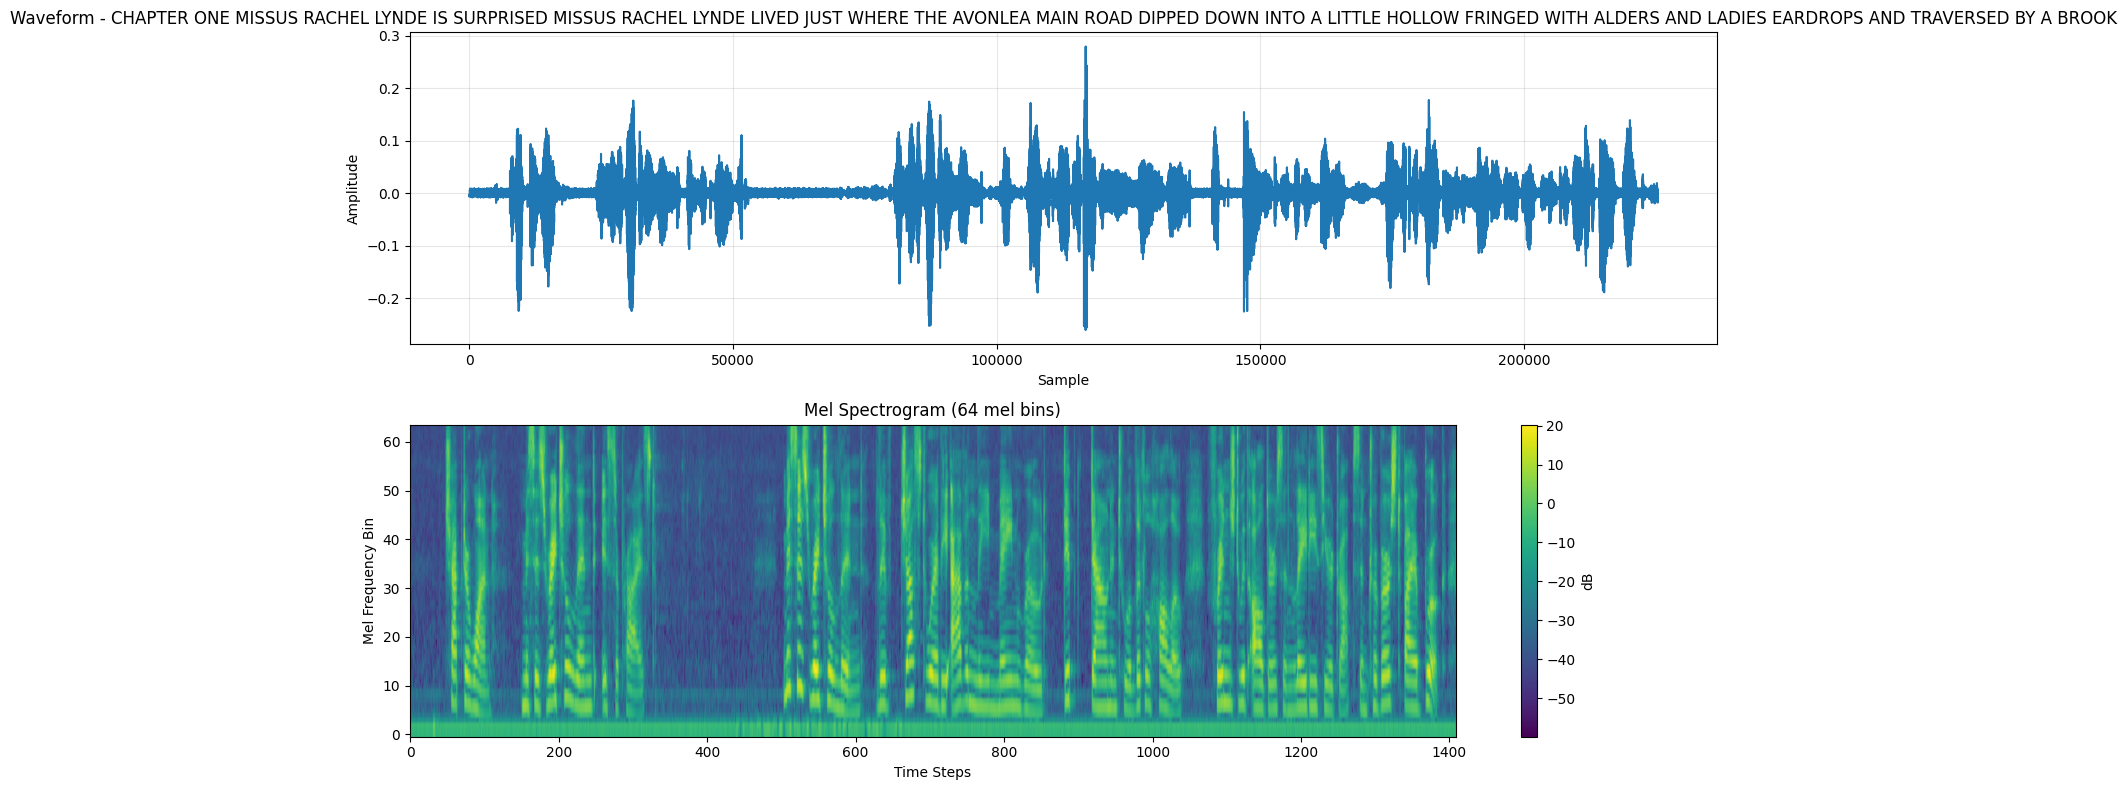

In [8]:
import torchaudio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Dataset setup
root = "/home/student/GOATS422/Notarius/Datasets"
train_ds = torchaudio.datasets.LIBRISPEECH(root=root, url="train-clean-100", download=False)

# Spectrogram transform (same as in model.py)
spec_transform = nn.Sequential(
    torchaudio.transforms.MelSpectrogram(n_fft=400, sample_rate=16000, hop_length=160, n_mels=64),
    torchaudio.transforms.AmplitudeToDB(stype="power", top_db=80)
)

# Load a random sample
sample_idx = 0  # Change this to see different samples
waveform, sample_rate, transcript, speaker_id, chapter_id, utterance_id = train_ds[sample_idx]

print(f"Sample Index: {sample_idx}")
print(f"Transcript: {transcript}")
print(f"Speaker ID: {speaker_id}")
print(f"Sample Rate: {sample_rate} Hz")
print(f"Waveform Shape: {waveform.shape}")

# Apply spectrogram transform
# waveform is already (1, n_samples), so pass it directly
spectrogram = spec_transform(waveform).squeeze(0)

print(f"Spectrogram Shape: {spectrogram.shape}")  # (n_mels, time_steps)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot waveform
axes[0].plot(waveform.squeeze().numpy())
axes[0].set_title(f"Waveform - {transcript}")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# Plot spectrogram
im = axes[1].imshow(spectrogram.numpy(), aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title("Mel Spectrogram (64 mel bins)")
axes[1].set_xlabel("Time Steps")
axes[1].set_ylabel("Mel Frequency Bin")
plt.colorbar(im, ax=axes[1], label="dB")

plt.tight_layout()
print("\nSpectrogram saved to: /home/student/GOATS422/Notarius/Outputs/spectrogram_sample.png")
plt.savefig("/home/student/GOATS422/Notarius/Outputs/spectrogram_sample.png")
plt.show()
